# Tutorial 2: Run ToxPredictor model

### 📘 Overview

This notebook takes the pathway signatures generated in the previous step and applies ToxPredictor to estimate DILI risk for each compound and dose.

**Inputs**  
Pathway-level gene signatures per compound and dose

**Output**  
Predicted DILI risk

In [ ]:
%%capture

!pip install scikit-learn==1.4.0

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dilimap as dmap

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
dmap.logging.print_version()

Running dilimap 1.0.2 (python 3.10.16) on 2025-06-29 15:22.


## 1. DILI prediction

* Load the pre-trained ToxPredictor model pre-trained on the DILImap library. 
* The model uses an ensemble of random forests to map pathway signatures to DILI risk.

In [4]:
# Load pathway signatures processed in the previous tutorial notebook
adata = dmap.s3.read('demo_data_pathways.h5ad')

Package: s3://dilimap/public/data. Top hash: f8d8274caa


In [5]:
# Load the pre-trained ToxPredictor model
model = dmap.models.ToxPredictor('v1')

Package: s3://dilimap/public/models. Top hash: b119d5a238
Package: s3://dilimap/public/data. Top hash: f8d8274caa


In [6]:
# Make model prediction to return dose-specific DILI risk probabilities.
df_res = model.predict(adata)

2 out of 186 features are missing from your data and have been filled with zeros. You can access the features available in the training data via `model.features`.
237 out of 421 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


In [7]:
from dilimap.utils import crosstab

adata.obs['DILI_prob'] = df_res['DILI_probability']
df_crosstab = crosstab(adata, ['compound_name', 'dose_level', 'DILI_prob'])[
    ['Low', 'Middle', 'Mid-High', 'High']
]
display(
    df_crosstab.style.format(precision=2).background_gradient(
        'RdBu_r', vmin=-0.2, vmax=1.25
    )
)

dose_level,Low,Middle,Mid-High,High
compound_name,,,,
Almotriptan,0.00,0.00,0.00,0.03
Brompheniramine,0.00,0.00,0.00,0.01
Chlorpromazine,nan,nan,nan,0.80
Darunavir,0.00,0.60,0.72,0.65
Tolvaptan,0.00,0.00,0.58,0.92


## 2. Safety margins

* Safety margins are calculated as the ratio of the first DILI dose (first dose with >0.7 predicted risk) to the therapeutic Cmax.
* This provides a quantitative proxy for a drug’s clinical safety window.

In [8]:
cmax = {
    'Almotriptan': 0.16,  # DILI negative
    'Brompheniramine': 0.04,  # DILI negative
    'Chlorpromazine': 0.7,  # positive plate control
    'Darunavir': 20.44,  # DILI positive
    'Tolvaptan': 0.40,  # DILI positive
}

adata.obs['Cmax_uM'] = adata.obs_names.map(cmax)

In [9]:
# Use dose-resolved predictions and human Cmax to compute safety margins.

df_res_MOS = model.compute_safety_margin(adata, 'compound_name', 'dose_uM', 'Cmax_uM')

2 out of 186 features are missing from your data and have been filled with zeros. You can access the features available in the training data via `model.features`.
237 out of 421 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


In [10]:
df_res_MOS

,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification
compound_name,,,,,,
Almotriptan,0.16,NaN,300,300.000000,none,-
Brompheniramine,0.04,NaN,300,300.000000,none,-
Chlorpromazine,0.70,10.0,300,14.285714,Transcriptomics,+
Darunavir,20.44,333.0,300,16.291585,Transcriptomics,+
Tolvaptan,0.40,10.0,300,25.000000,Transcriptomics,+


## 3. DILI dose response curves

* We visualize DILI risk probabilities across dose levels.
* Confidence intervals are estimated from the standard deviation of 30 model estimators.

In [11]:
# Make DILI probabilities across estimators to compute confidence invervals

adata.obs['DILI_prob_std'] = model.predict_proba_across_estimators(adata).std(1)

2 out of 186 features are missing from your data and have been filled with zeros. You can access the features available in the training data via `model.features`.
237 out of 421 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


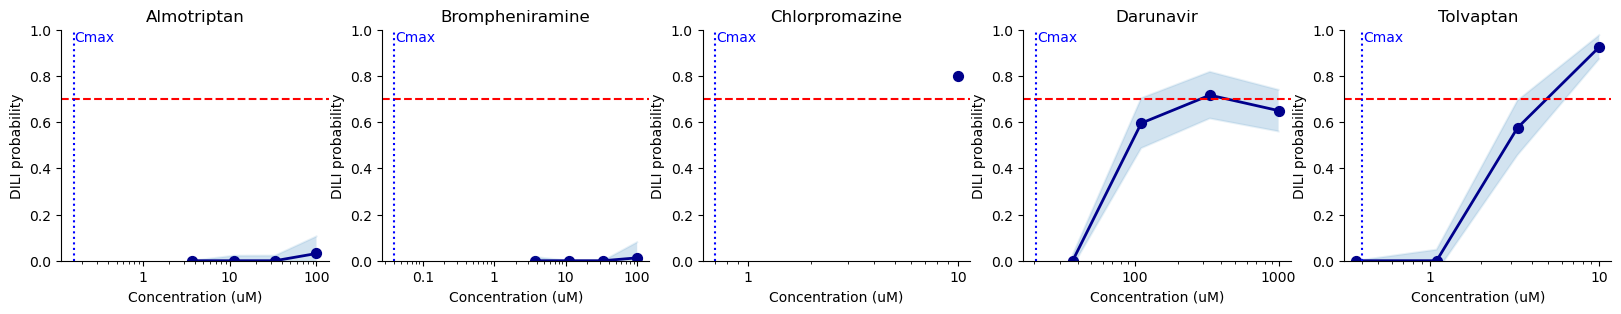

In [12]:
# Visualize dose-resolved DILI risk probalities along with confidence intervals

from matplotlib.ticker import FuncFormatter

cmpds = adata.obs_names.unique()

fig, axs = plt.subplots(1, len(cmpds), figsize=(4 * len(cmpds), 3))

for i, cmpd in enumerate(cmpds):
    y_mean = adata[cmpd].obs['DILI_prob']
    y_std = adata[cmpd].obs['DILI_prob_std']

    error = y_std
    lower = y_mean - 2.576 * error
    upper = y_mean + 2.576 * error

    df = adata[cmpd].obs[['dose_uM', 'DILI_prob']]
    x = adata[cmpd].obs['dose_uM'].values

    axs[i].plot(x, lower, color='tab:blue', alpha=0.1)
    axs[i].plot(x, upper, color='tab:blue', alpha=0.1)
    axs[i].fill_between(x, lower, upper, alpha=0.2)

    axs[i].scatter(x, y_mean, color='darkblue', s=50)
    axs[i].plot(x, y_mean, label='DILI_prob', color='darkblue', linewidth=2)

    axs[i].set_xlabel('Concentration (uM)')
    axs[i].set_ylabel('DILI probability')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].axhline(0.7, linestyle='--', color='red')
    drug_cmax = adata[cmpd].obs['Cmax_uM'].iloc[0]
    if drug_cmax is not np.nan:
        axs[i].axvline(drug_cmax, linestyle=':', color='b')  #'-', '--', '-.',
        axs[i].annotate('Cmax', (drug_cmax * 1.02, 0.95), color='b')
    # axs[i].annotate('DILI cutoff', (np.min(x)*0.95, 0.72), c='red')

    axs[i].set_ylim(0, 1)
    axs[i].set_xscale('log')
    axs[i].set_title(cmpd)
    # ax.legend(loc='lower right')

    axs[i].xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: (
                '{{:.{:1d}f}}'.format(int(np.maximum(-np.log10(x), 0)))
            ).format(x)
        )
    )

plt.show()

## 4. DILI risk dose regimes

- We compute safety margins across a range of hypothetical Cmax values.
- Use cumulative likelihoods to determine whether the compounds' Cmax corresponds to a high- or low-risk dosing regime.
- It also supports safe dose recommendations by providing the maximum possible Cmax within the low-risk regime. 

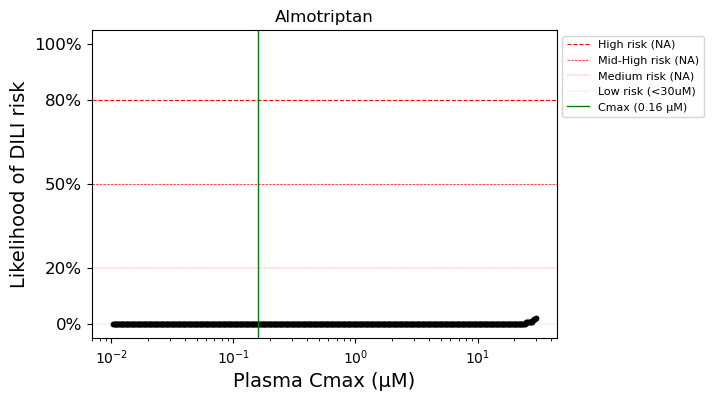

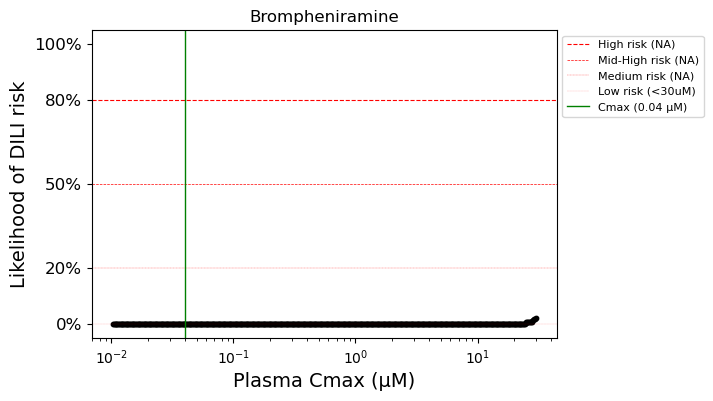

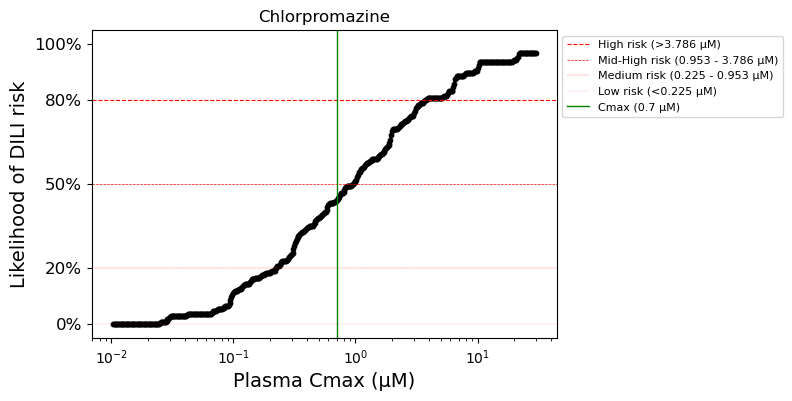

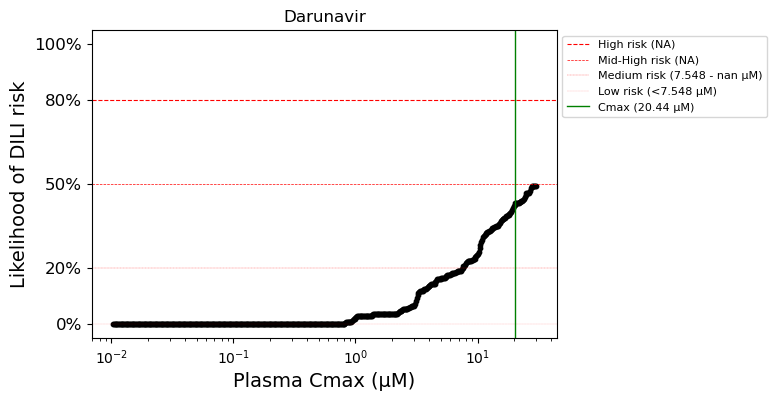

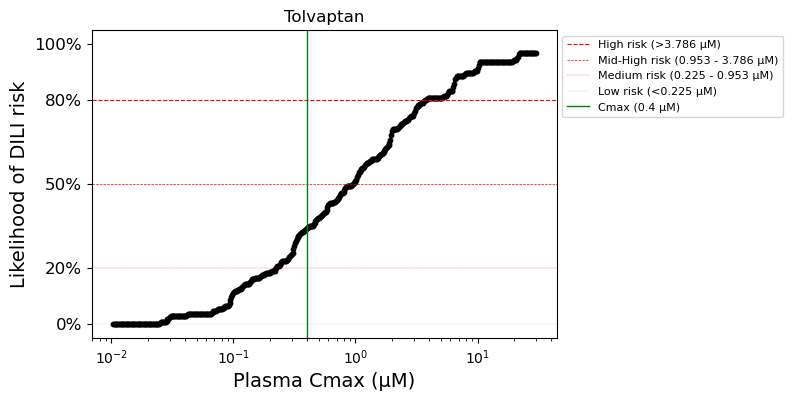

In [13]:
for cmpd in adata.obs['compound_name'].unique():
    model.plot_DILI_dose_regimes(cmpd)